Import Thư viện & Cấu hình Hệ thống

In [1]:
# ==========================================
# 1. System, File & Data Processing
# ==========================================
import os
import sys
import time
import warnings
from pathlib import Path
import joblib  # Lưu và nạp mô hình / Pipeline sau khi huấn luyện

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from tqdm.notebook import tqdm  # Hiển thị thanh tiến trình trong Jupyter Notebook

# ==========================================
# 2. Imbalanced-Learn (Xử lý mất cân bằng dữ liệu)
# ==========================================
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, SMOTENC  # SMOTENC dùng cho cả thuộc tính số & phân loại
from imblearn.under_sampling import RandomUnderSampler  # Giảm mẫu
from imblearn.combine import SMOTEENN  # Kết hợp Over & Under sampling

# ==========================================
# 3. Scikit-Learn Preprocessing & Imputation
# ==========================================
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    OneHotEncoder, OrdinalEncoder, LabelEncoder
)
from sklearn.impute import SimpleImputer, KNNImputer  # Xử lý dữ liệu khuyết (Missing Values)
from sklearn.compose import ColumnTransformer

# ==========================================
# 4. Model Selection & Cross-Validation
# ==========================================
from sklearn.model_selection import (
    train_test_split,       # Chia dữ liệu Train/Test (CỰC KỲ QUAN TRỌNG)
    StratifiedKFold, KFold,
    GridSearchCV, RandomizedSearchCV,  # RandomizedSearch cho không gian tham số lớn
    cross_validate, cross_val_score
)

# ==========================================
# 5. Metrics & Model Evaluation
# ==========================================
from sklearn.metrics import (
    classification_report, f1_score, roc_auc_score, accuracy_score,
    precision_score, recall_score, confusion_matrix, roc_curve, precision_recall_curve,
    make_scorer, log_loss, matthews_corrcoef,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)

# ==========================================
# 6. Machine Learning Models
# ==========================================
# Baseline Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# Tree-based & Ensemble Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, 
    AdaBoostClassifier, ExtraTreesClassifier
)

# Boosting Frameworks
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier  # Bổ sung CatBoost cho đủ bộ 3 Boosting

# ==========================================
# 7. Model Explainability / XAI (Tùy chọn)
# ==========================================
import shap  # Phân tích Feature Importance nâng cao với SHAP values

# ==========================================
# 8. Cấu hình giao diện đồ thị & Cảnh báo
# ==========================================
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
warnings.filterwarnings('ignore')

print("=== TẤT CẢ CÁC THƯ VIỆN ĐÃ ĐƯỢC IMPORT THÀNH CÔNG ===")


=== TẤT CẢ CÁC THƯ VIỆN ĐÃ ĐƯỢC IMPORT THÀNH CÔNG ===


C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Đọc dữ liệu Train & Test độc lập

In [2]:
train_df = pd.read_csv('D:/DS66B_group_11/data/processed/train.csv')
test_df = pd.read_csv('D:/DS66B_group_11/data/processed/test.csv')

print(f"Kích thước tập Train (Train shape): {train_df.shape}")
print(f"Kích thước tập Test (Test shape)  : {test_df.shape}")

# Hiển thị 5 dòng đầu tập Train
train_df.head()

Kích thước tập Train (Train shape): (5634, 21)
Kích thước tập Test (Test shape)  : (1409, 21)


,customerID,tenure,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,...,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,4950-BDEUX,35,49.20,1701.65,Male,0,No,No,No,No,...,No,No,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,0
1,7993-NQLJE,15,75.10,1151.55,Male,0,Yes,Yes,Yes,No,...,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,0
2,7321-ZNSLA,13,40.55,590.35,Male,0,Yes,Yes,No,No,...,Yes,Yes,No,Yes,No,No,Two year,No,Mailed check,0
3,4922-CVPDX,26,73.50,1905.70,Female,0,Yes,No,Yes,No,...,No,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),0
4,2903-YYTBW,1,44.55,44.55,Male,0,Yes,Yes,Yes,No,...,No,No,No,No,No,No,Month-to-month,No,Electronic check,0


Kiểm định Thống kê Suy diễn (Chi-square & Cramer's V)

In [3]:
# Lọc các cột phân loại (Object/Categorical)
cat_cols = train_df.select_dtypes(include=['object', 'category']).columns.tolist()
if 'customerID' in cat_cols: cat_cols.remove('customerID')
if 'Churn' in cat_cols: cat_cols.remove('Churn')

def cramers_v(x, y):
    confusion_m = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_m)[0]
    n = confusion_m.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_m.shape
    return np.sqrt(phi2 / min((k - 1), (r - 1)))

chi2_results = []
for col in cat_cols:
    contingency = pd.crosstab(train_df[col], train_df['Churn'])
    chi2, p, dof, _ = chi2_contingency(contingency)
    v = cramers_v(train_df[col], train_df['Churn'])
    chi2_results.append({'Feature': col, 'Chi2_Stat': round(chi2, 4), 'p_value': p, 'Cramers_V': round(v, 4)})

chi2_table = pd.DataFrame(chi2_results).sort_values(by='Cramers_V', ascending=False)

print("Table 1: Inferential Statistical Tests (Chi-Square & Cramer's V) on Categorical Features")
print(chi2_table.to_string(index=False))

Table 1: Inferential Statistical Tests (Chi-Square & Cramer's V) on Categorical Features
         Feature  Chi2_Stat       p_value  Cramers_V
        Contract   952.3080 1.617851e-207     0.4111
 InternetService   600.8466 3.371396e-131     0.3266
   PaymentMethod   545.2144 7.571919e-118     0.3111
PaperlessBilling   219.9225  9.403694e-50     0.1976
  OnlineSecurity   170.8442  4.839368e-39     0.1741
      Dependents   157.1637  4.713996e-36     0.1670
     TechSupport   153.9081  2.425610e-35     0.1653
         Partner   118.9693  1.063622e-27     0.1453
    OnlineBackup    37.8896  7.486409e-10     0.0820
     StreamingTV    29.1942  6.547379e-08     0.0720
 StreamingMovies    22.6274  1.966589e-06     0.0634
DeviceProtection    21.1030  4.352547e-06     0.0612
   MultipleLines    10.5922  1.135683e-03     0.0434
    PhoneService     1.6776  1.952455e-01     0.0173
          gender     0.0184  8.921968e-01     0.0018


Thiết lập Preprocessing ColumnTransformer & Pipeline Anti-Leakage

In [4]:
# Chuyển đổi nhãn Target về dạng nhị phân 0/1
y_train = train_df['Churn'].map({'Yes': 1, 'No': 0, 1: 1, 0: 0})
X_train = train_df.drop(columns=['Churn', 'customerID'], errors='ignore')

if 'Churn' in test_df.columns:
    y_test = test_df['Churn'].map({'Yes': 1, 'No': 0, 1: 1, 0: 0})
    X_test = test_df.drop(columns=['Churn', 'customerID'], errors='ignore')
else:
    y_test = None
    X_test = test_df.drop(columns=['customerID'], errors='ignore')

# Xác định danh sách cột số học và định tính ban đầu
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# BỔ SUNG: Loại bỏ các feature rác dựa trên p-value >= 0.05 từ bảng chi2_table
significant_cat_cols = chi2_table[chi2_table['p_value'] < 0.05]['Feature'].tolist()
removed_cat_cols = [col for col in cat_cols if col not in significant_cat_cols]
cat_cols = [col for col in cat_cols if col in significant_cat_cols]

print(f"[Feature Selection] Đã loại bỏ các biến rác (p-value >= 0.05): {removed_cat_cols}")
print(f"[Feature Selection] Giữ lại {len(cat_cols)} biến định tính có ý nghĩa thống kê (p < 0.05).")

# Cập nhật X_train và X_test chỉ chứa các đặc trưng đã chọn
X_train = X_train[num_cols + cat_cols]
if X_test is not None:
    X_test = X_test[num_cols + cat_cols]

# ColumnTransformer xử lý dữ liệu
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols)
    ]
)

print(f"Xử lý thành công Pipeline Preprocessor cho {len(num_cols)} cột số và {len(cat_cols)} cột định tính.")


[Feature Selection] Đã loại bỏ các biến rác (p-value >= 0.05): ['gender', 'PhoneService']
[Feature Selection] Giữ lại 13 biến định tính có ý nghĩa thống kê (p < 0.05).
Xử lý thành công Pipeline Preprocessor cho 4 cột số và 13 cột định tính.


Đánh giá Cross-Validation An toàn dữ liệu (In-Pipeline SMOTE + Stratified 5-Fold)

In [5]:
cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Tính tỷ lệ class imbalanced để dùng cho XGBoost scale_pos_weight
pos_weight_ratio = (y_train == 0).sum() / (y_train == 1).sum()

# Khai báo các mô hình cho phương pháp 1: SMOTE (Không dùng class_weight)
models_smote = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1)
}

# Khai báo các mô hình cho phương pháp 2: Class Weight Balanced (Không dùng SMOTE)
models_balanced = {
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=pos_weight_ratio),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1, class_weight='balanced')
}

cv_results_list = []

# Task 1.6: Chạy đối chiếu hiệu năng giữa Anti-Leakage SMOTE vs Class Weight Balanced
for name in models_smote.keys():
    # 1. Pipeline với Anti-Leakage SMOTE
    pipe_smote = ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', models_smote[name])
    ])
    s_smote = cross_validate(pipe_smote, X_train, y_train, cv=cv_stratified,
                             scoring=['f1', 'roc_auc', 'recall', 'precision'], n_jobs=-1)
    
    # 2. Pipeline với Class Weight Balanced (Cost-Sensitive Learning)
    pipe_bal = ImbPipeline([
        ('preprocessor', preprocessor),
        ('classifier', models_balanced[name])
    ])
    s_bal = cross_validate(pipe_bal, X_train, y_train, cv=cv_stratified,
                           scoring=['f1', 'roc_auc', 'recall', 'precision'], n_jobs=-1)
    
    # Lưu kết quả SMOTE
    cv_results_list.append({
        'Model': name,
        'Sampling Method': 'SMOTE Pipeline',
        'F1-Score Mean': np.mean(s_smote['test_f1']),
        'ROC-AUC Mean': np.mean(s_smote['test_roc_auc']),
        'Recall Mean': np.mean(s_smote['test_recall']),
        'Precision Mean': np.mean(s_smote['test_precision'])
    })
    
    # Lưu kết quả Class Weight Balanced
    cv_results_list.append({
        'Model': name,
        'Sampling Method': 'Class Weight Balanced',
        'F1-Score Mean': np.mean(s_bal['test_f1']),
        'ROC-AUC Mean': np.mean(s_bal['test_roc_auc']),
        'Recall Mean': np.mean(s_bal['test_recall']),
        'Precision Mean': np.mean(s_bal['test_precision'])
    })

cv_results_df = pd.DataFrame(cv_results_list).sort_values(by='F1-Score Mean', ascending=False)

print("Table 2: Đối chiếu Hiệu năng Baseline: In-Pipeline SMOTE vs Class Weight Balanced")
print(cv_results_df.to_string(index=False))


Table 2: Đối chiếu Hiệu năng Baseline: In-Pipeline SMOTE vs Class Weight Balanced
        Model       Sampling Method  F1-Score Mean  ROC-AUC Mean  Recall Mean  Precision Mean
     LightGBM Class Weight Balanced       0.627163      0.837232     0.739130        0.544757
     LightGBM        SMOTE Pipeline       0.602752      0.832399     0.607358        0.598850
Random Forest Class Weight Balanced       0.602565      0.822874     0.638127        0.571095
      XGBoost Class Weight Balanced       0.597851      0.821804     0.662876        0.544604
Random Forest        SMOTE Pipeline       0.585489      0.821922     0.582609        0.588616
      XGBoost        SMOTE Pipeline       0.575779      0.820328     0.572575        0.579427
Decision Tree        SMOTE Pipeline       0.518200      0.673281     0.551171        0.489153
Decision Tree Class Weight Balanced       0.508737      0.666422     0.502341        0.515967


Tinh chỉnh Siêu tham số (Hyperparameter Tuning) qua GridSearch

In [6]:
# Lập Pipeline chuẩn cho GridSearch với LightGBM
tune_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LGBMClassifier(random_state=42, verbose=-1))
])

# Lập không gian tham số GridSearch cho LightGBM
param_grid_lgb = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5, -1],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__num_leaves': [15, 31]
}

grid_lgb = GridSearchCV(
    estimator=tune_pipeline,
    param_grid=param_grid_lgb,
    cv=cv_stratified,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("=== ĐANG CHẠY GRIDSEARCH TUNING CHO LIGHTGBM ===")
grid_lgb.fit(X_train, y_train)

best_lgb_model = grid_lgb.best_estimator_
print("\nBộ siêu tham số LightGBM tối ưu nhất (Best Parameters):")
print(grid_lgb.best_params_)

=== ĐANG CHẠY GRIDSEARCH TUNING CHO LIGHTGBM ===
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Bộ siêu tham số LightGBM tối ưu nhất (Best Parameters):
{'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__num_leaves': 15}


Trực quan hóa Bảng So sánh Hiệu năng & Đồ thị Đánh giá Tập Test

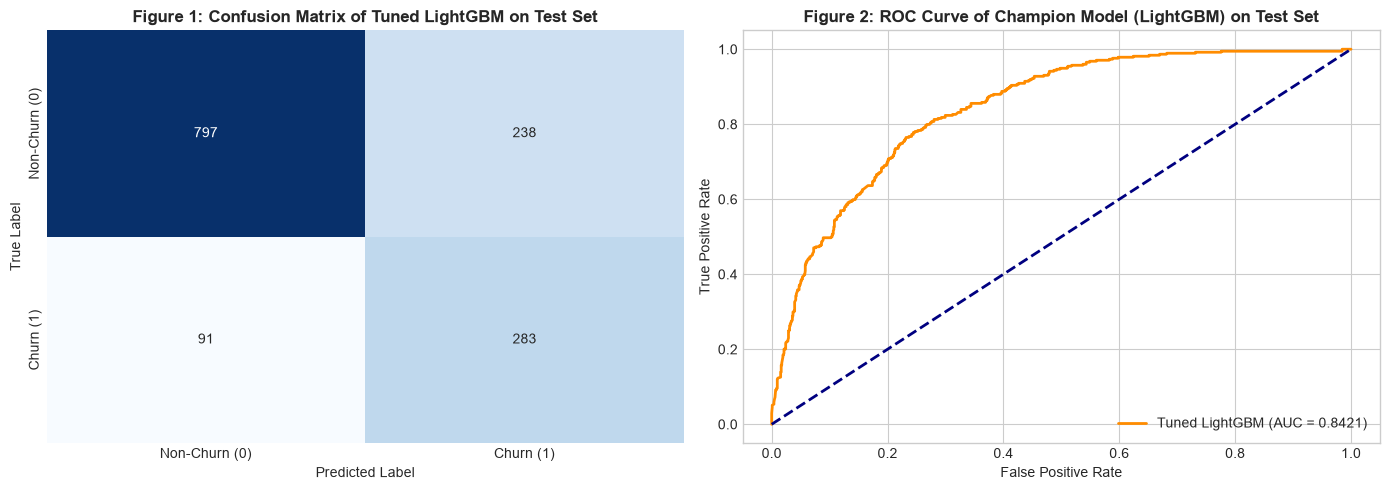

In [7]:
# Cell 7: Dự đoán trên tập Test độc lập & Trực quan hóa kết quả mô hình Tuned LightGBM
y_pred_test = best_lgb_model.predict(X_test)
y_prob_test = best_lgb_model.predict_proba(X_test)[:, 1]

# Cấu hình Biểu đồ ROC Curve & Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Figure 1: Confusion Matrix of Tuned LightGBM on Test Set', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_xticklabels(['Non-Churn (0)', 'Churn (1)'])
axes[0].set_yticklabels(['Non-Churn (0)', 'Churn (1)'])

# 2. Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
test_auc = roc_auc_score(y_test, y_prob_test)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'Tuned LightGBM (AUC = {test_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_title('Figure 2: ROC Curve of Champion Model (LightGBM) on Test Set', fontsize=12, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

Tối ưu hóa Ngưỡng Xác suất (Threshold Tuning)

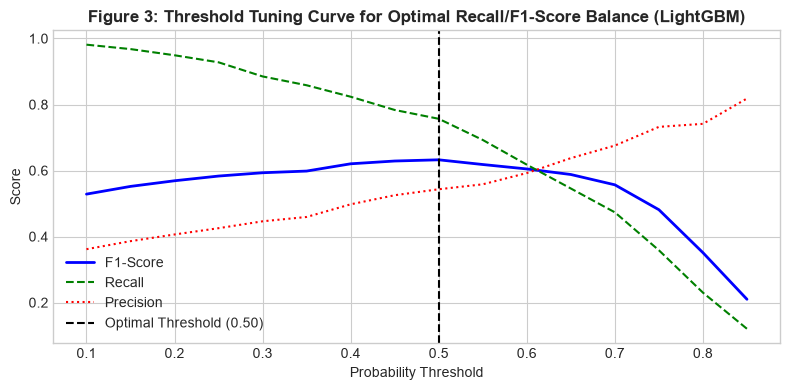

Ngưỡng tối ưu nhất (Best Threshold): 0.50
F1-Score cao nhất đạt được      : 0.6324
Recall tương ứng                : 0.7567


In [8]:
# Cell 8: Threshold Tuning (Tối ưu ngưỡng xác suất quyết định cho LightGBM)
thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores = []
recall_scores = []
precision_scores = []

for t in thresholds:
    y_pred_adj = (y_prob_test >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_adj))
    recall_scores.append(recall_score(y_test, y_pred_adj))
    precision_scores.append(precision_score(y_test, y_pred_adj))

# Tìm ngưỡng đạt F1-Score cao nhất
best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]

# Vẽ đồ thị Threshold vs Metrics
plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores, label='F1-Score', color='blue', lw=2)
plt.plot(thresholds, recall_scores, label='Recall', color='green', linestyle='--')
plt.plot(thresholds, precision_scores, label='Precision', color='red', linestyle=':')
plt.axvline(best_thresh, color='black', linestyle='--', label=f'Optimal Threshold ({best_thresh:.2f})')

plt.title('Figure 3: Threshold Tuning Curve for Optimal Recall/F1-Score Balance (LightGBM)', fontsize=12, fontweight='bold')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Ngưỡng tối ưu nhất (Best Threshold): {best_thresh:.2f}")
print(f"F1-Score cao nhất đạt được      : {f1_scores[best_idx]:.4f}")
print(f"Recall tương ứng                : {recall_scores[best_idx]:.4f}")

Diễn giải Tầm quan trọng của Biến (Feature Importance / SHAP Values)

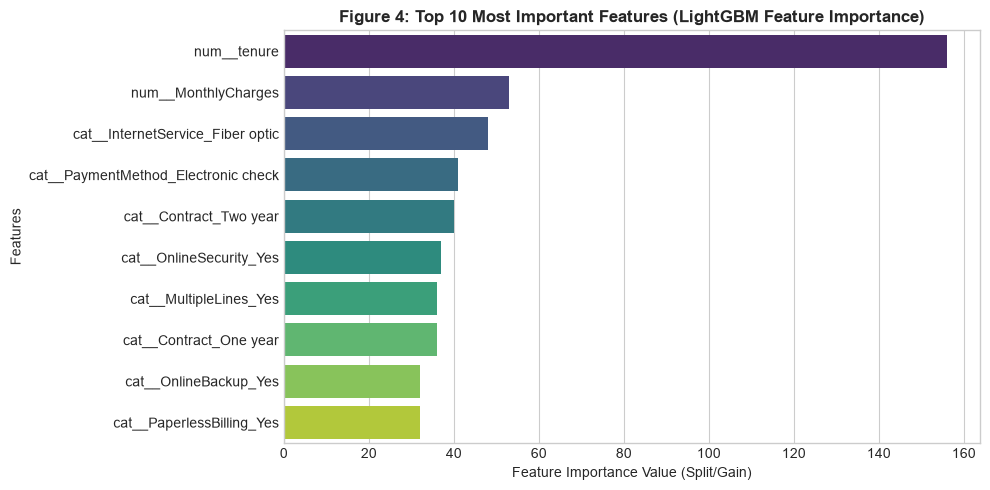

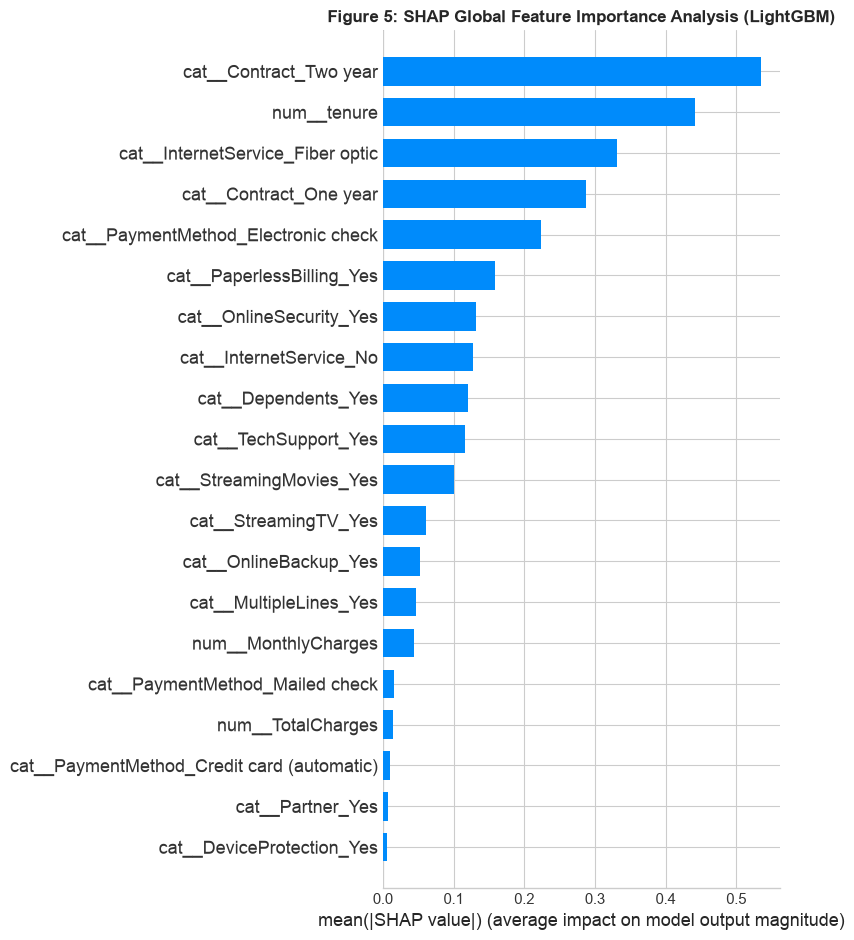

In [9]:
# Cell 9: Feature Importance & SHAP Values Analysis cho LightGBM
import shap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Trích xuất preprocessor VÀ classifier ĐÃ DỰNG (fitted) từ best_lgb_model
fitted_preprocessor = best_lgb_model.named_steps['preprocessor']
lgb_clf = best_lgb_model.named_steps['classifier']

# Lấy danh sách tên đặc trưng từ preprocessor đã fit
feature_names = fitted_preprocessor.get_feature_names_out()

# Trích xuất Feature Importance gốc từ LightGBM
importances = lgb_clf.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(10)

# Biểu đồ Top 10 Feature Importance
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Figure 4: Top 10 Most Important Features (LightGBM Feature Importance)', fontsize=12, fontweight='bold')
plt.xlabel('Feature Importance Value (Split/Gain)')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# 2. Biến đổi dữ liệu X_test bằng preprocessor ĐÃ FIT
X_test_transformed = fitted_preprocessor.transform(X_test)
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# Tính toán SHAP Values
explainer = shap.Explainer(lgb_clf)
shap_values = explainer(X_test_transformed)

# Biểu đồ SHAP Global Feature Importance
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, plot_type="bar", show=False)
plt.title('Figure 5: SHAP Global Feature Importance Analysis (LightGBM)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()